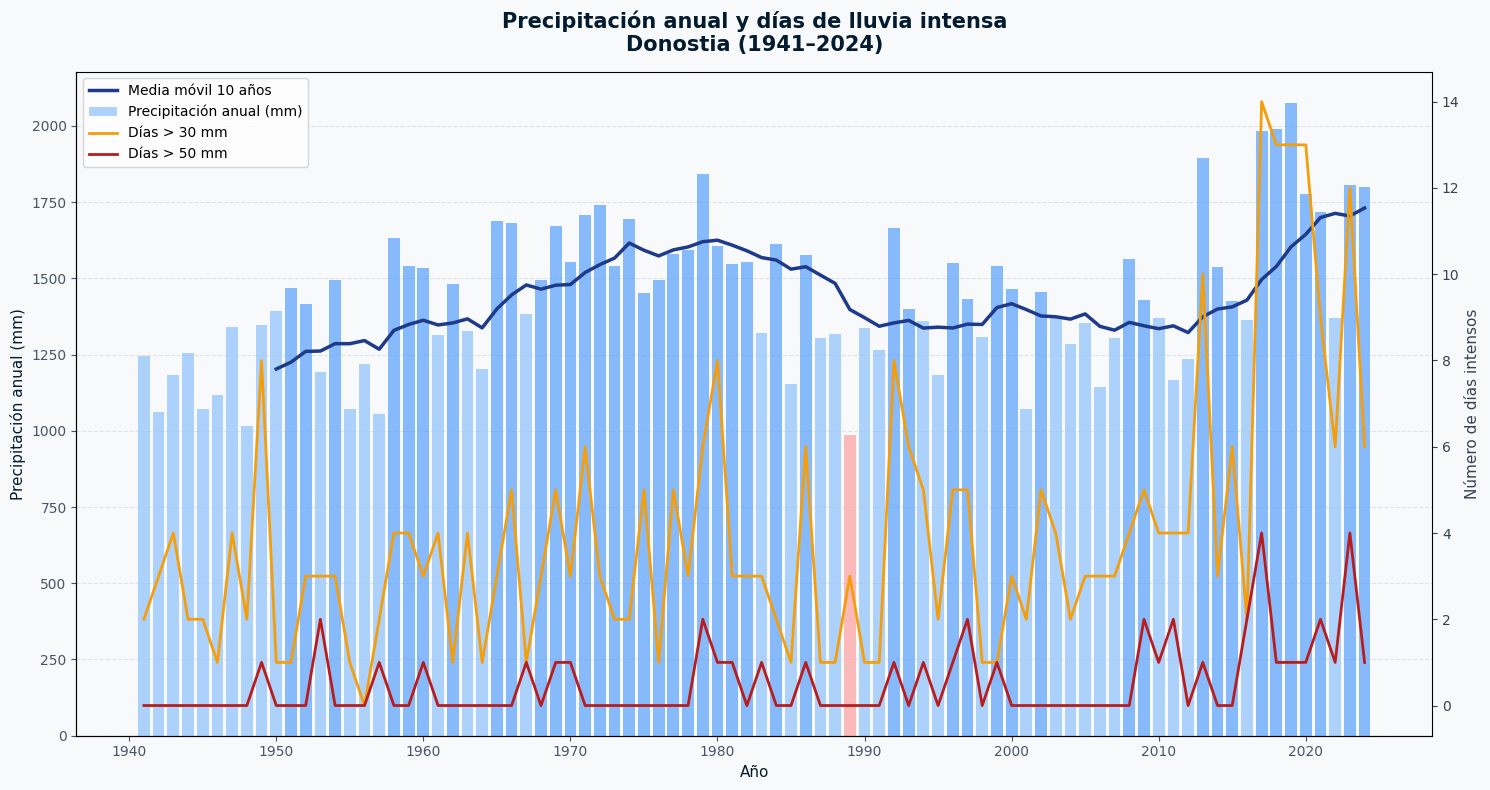

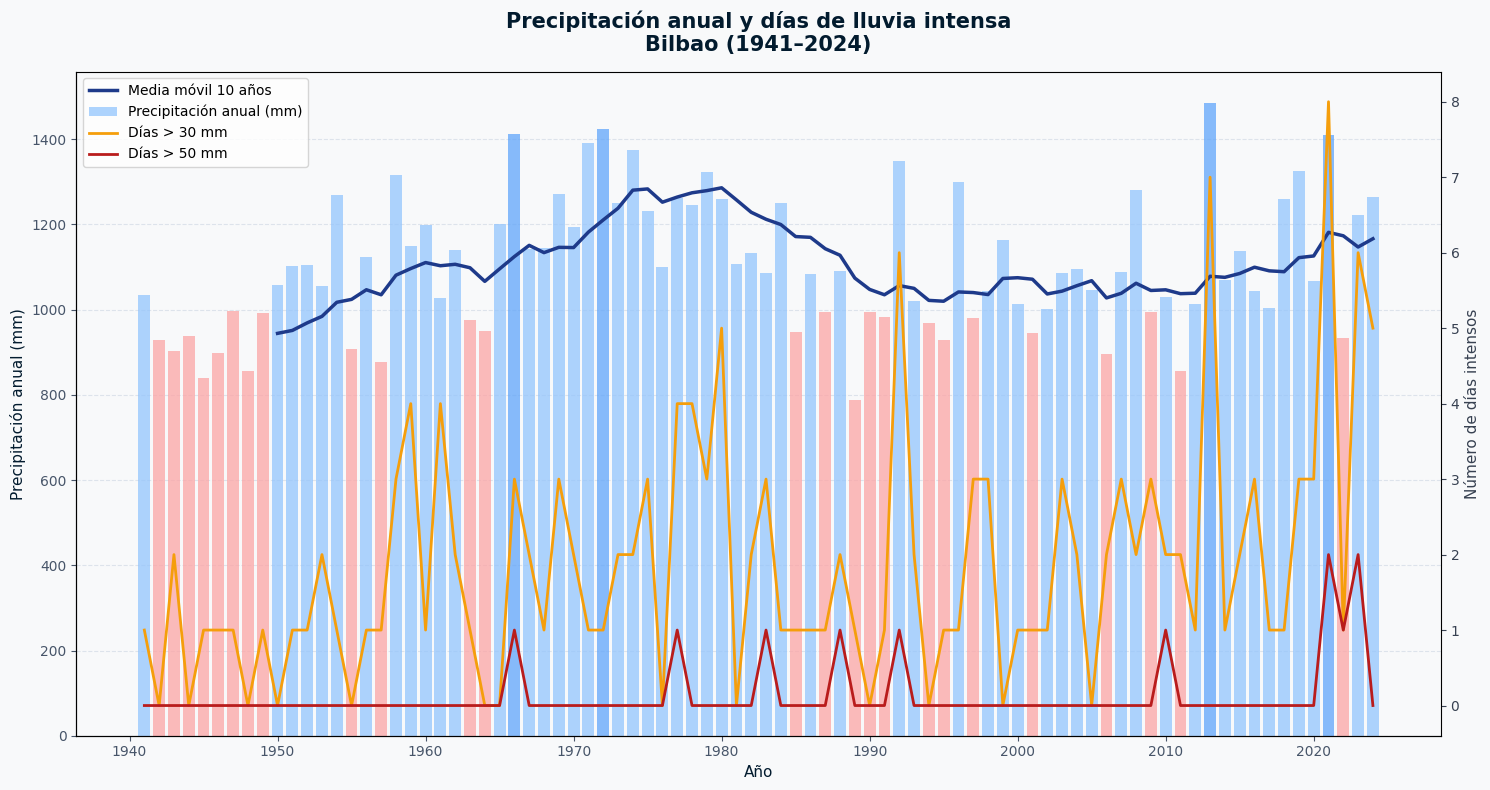

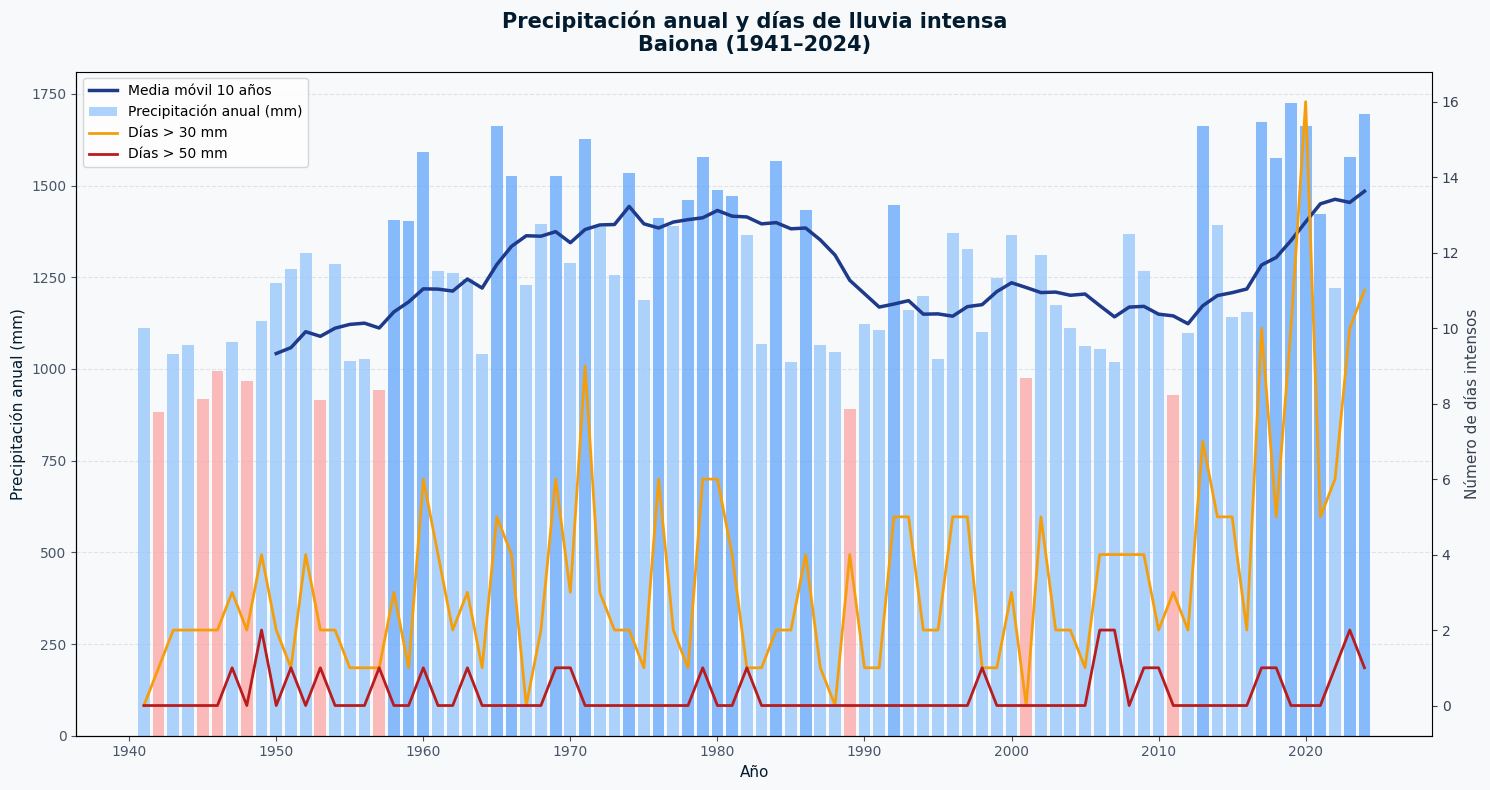

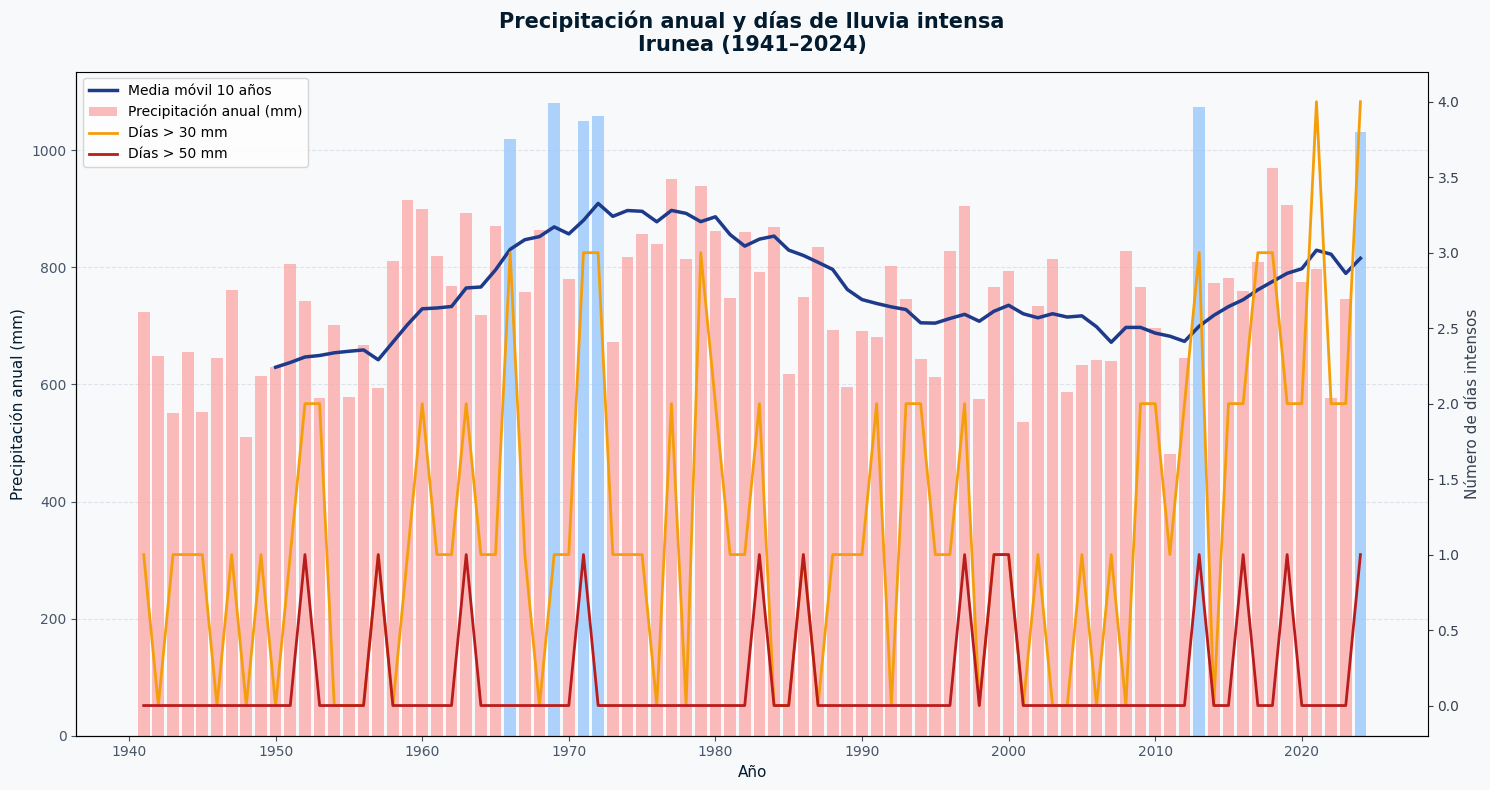

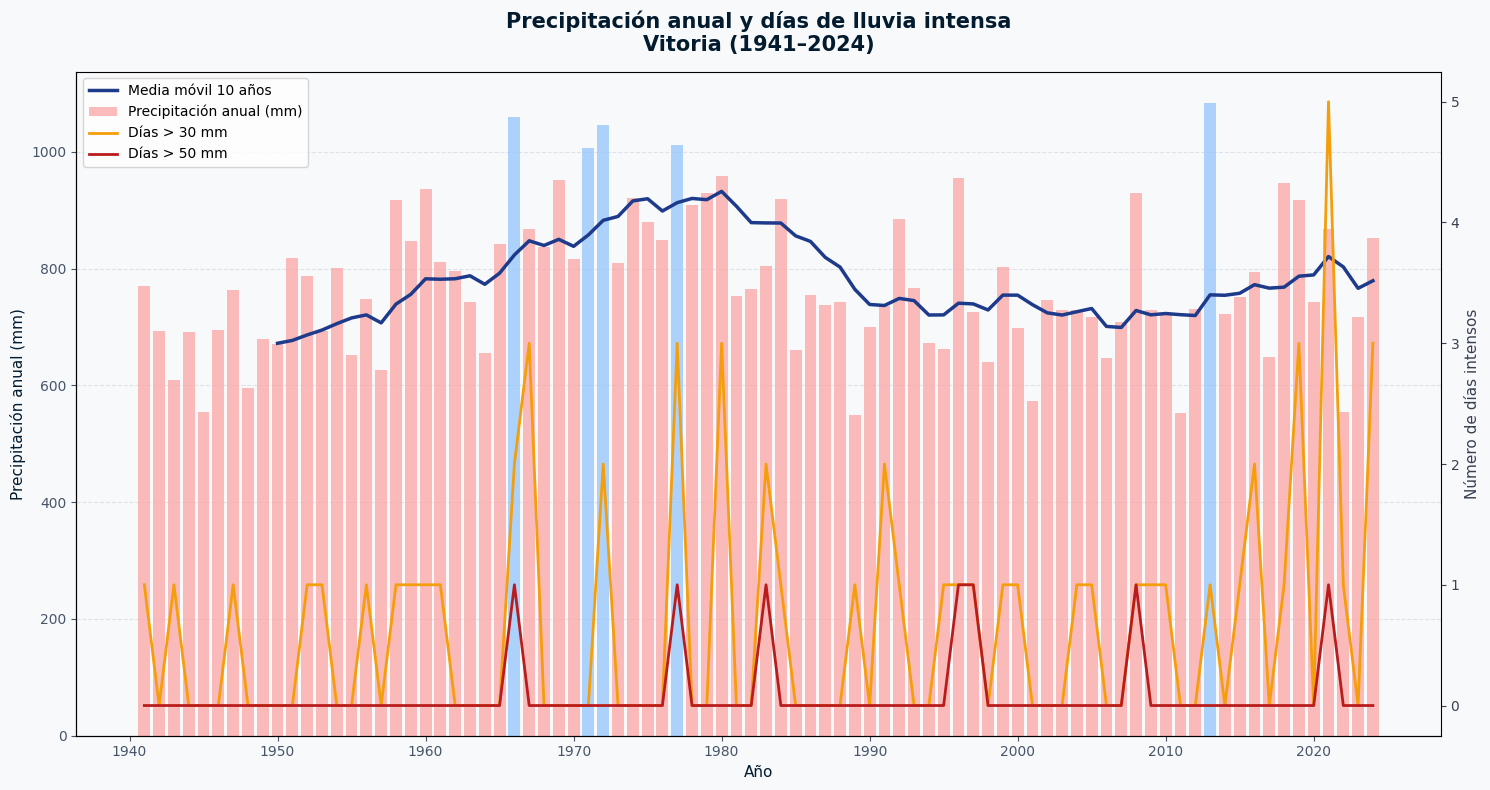

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from variables import csv_list

dfs = {}

# Cargar datos
for csv in csv_list:
    nombre = csv.split('_')[1].replace('.csv', '')
    dfs[nombre] = pd.read_csv(csv)

for csv_name in dfs:
    df = dfs[csv_name]

    # ───────────────────────────────────────────────
    # PRECIPITACIÓN TOTAL ANUAL
    # ───────────────────────────────────────────────
    df_precip = df.groupby('año')['precipitation_sum'].sum()

    años = df_precip.index.tolist()
    precip = df_precip.values

    # ───────────────────────────────────────────────
    # MEDIA MÓVIL (10 años)
    # ───────────────────────────────────────────────
    window = 10
    media_movil = np.convolve(precip, np.ones(window)/window, mode='valid')
    años_mm = años[window-1:]

    # ───────────────────────────────────────────────
    # FIGURA
    # ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    # Colores según nivel de precipitación
    colors = ['#60A5FA' if p >= 1400 else '#93C5FD' if p >= 1000 else '#FCA5A5' for p in precip]

    ax.bar(años, precip, color=colors, alpha=0.75, width=0.8, zorder=2)

    # Media móvil
    ax.plot(años_mm, media_movil, color='#1E3A8A', linewidth=2.5,
            label=f'Media móvil {window} años', zorder=3)

    # ───────────────────────────────────────────────
    # ESTILO
    # ───────────────────────────────────────────────
    ax.set_title(f'Precipitación total anual\n{csv_name.capitalize()} (1941–2024)',
                 fontsize=14, fontweight='bold', color='#021B2E', pad=15)
    ax.set_xlabel('Año', fontsize=11, color='#021B2E')
    ax.set_ylabel('Precipitación anual (mm)', fontsize=11, color='#021B2E')
    ax.tick_params(colors='#475569')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(axis='y', color='#CBD5E1', linestyle='--', alpha=0.6, zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10)

    # Anotar años muy secos (< 800 mm)
    for año, p in zip(años, precip):
        if p < 800:
            ax.annotate(f'{int(p)}', xy=(año, p), xytext=(0, 5),
                        textcoords='offset points', ha='center',
                        fontsize=9, color='#B91C1C', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'grafico_precipitacion_{csv_name}.png', dpi=180, bbox_inches='tight')
    plt.show()
